In [1]:
!mkdir ~/.kaggle/

mkdir: cannot create directory ‘/root/.kaggle/’: File exists


In [2]:
!cp "/content/drive/MyDrive/kaggle/kaggle.json"  ~/.kaggle/kaggle.json


In [3]:
!python -m pip install -qq kaggle


In [4]:
# Download the datasets from kaggle

!kaggle datasets download -d gpiosenka/sports-classification

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/sports-classification
License(s): CC0-1.0
sports-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
# Unzip our file

import zipfile
zip_ref = zipfile.ZipFile("/content/sports-classification.zip")
zip_ref.extractall()
zip_ref.close()

In [23]:
# Walkthrough the file
import os

for dirpath, dirnames, filenames in os.walk("/content/test"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")


There are 100 directories and 0 images in /content/test
There are 0 directories and 5 images in /content/test/hydroplane racing
There are 0 directories and 5 images in /content/test/rowing
There are 0 directories and 5 images in /content/test/croquet
There are 0 directories and 5 images in /content/test/bike polo
There are 0 directories and 5 images in /content/test/track bicycle
There are 0 directories and 5 images in /content/test/ice climbing
There are 0 directories and 5 images in /content/test/olympic wrestling
There are 0 directories and 5 images in /content/test/gaga
There are 0 directories and 5 images in /content/test/baseball
There are 0 directories and 5 images in /content/test/rollerblade racing
There are 0 directories and 5 images in /content/test/trapeze
There are 0 directories and 5 images in /content/test/lacrosse
There are 0 directories and 5 images in /content/test/shot put
There are 0 directories and 5 images in /content/test/hang gliding
There are 0 directories and 

In [39]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/train"
valid_dir = "/content/valid"
test_dir = "/content/test"

# Rescale and augment the training data
train_datagen = ImageDataGenerator(rescale=1/255.,
                                   width_shift_range = .2,
                                   rotation_range = .2,
                                   height_shift_range = .2,
                                   shear_range=.2,
                                   zoom_range = .2,
                                   horizontal_flip = True)


valid_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# Load in the data
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224,224),
                                               class_mode = "categorical",
                                               batch_size = 32,
                                               )

valid_data = valid_datagen.flow_from_directory(valid_dir,
                                                  target_size=(224,224),
                                                  class_mode = "categorical",
                                                  batch_size = 32)

test_data = test_datagen.flow_from_directory(test_dir,
                                                  target_size=(224,224),
                                                  class_mode = "categorical",
                                                  batch_size = 32)

Found 13492 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Found 500 images belonging to 100 classes.


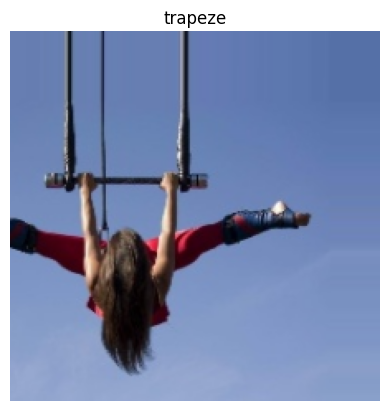

In [7]:
import matplotlib.pyplot as plt
import random
import numpy as np

images, labels = next(train_data)

# Pick a random index in the current batch
random_index = random.randint(0, 31)

# Reverse the class_indices dict to get index -> class name mapping
class_names = {v: k for k, v in train_data.class_indices.items()}

# Get the actual class index from the one-hot encoded label
class_index = np.argmax(labels[random_index])

# Get class name
class_name = class_names[class_index]

# Display the image with the correct label
plt.imshow(images[random_index])
plt.title(class_name)
plt.axis("off")
plt.show()

In [8]:
len(train_data.class_indices)

100

In [9]:
import tensorflow as tf
# Build the model
model_0 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size = 3,
                           activation = "relu",
                           input_shape=(224,224,3)
                           ),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(len(train_data.class_indices), activation="softmax")
])

In [ ]:
# Compile the model
model_0.compile(loss= 'categorical_crossentropy',
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

In [ ]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     2,809,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,812,110 (10.73 MB)

 Trainable params: 2,812,110 (10.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the model
model_0_history = model_0.fit(train_data,
                              batch_size =32,
                              epochs = 5,
                              steps_per_epoch = len(train_data),
                              validation_data = valid_data,
                              validation_steps = len(valid_data)
                              )

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 161s 376ms/step - accuracy: 0.0370 - loss: 4.4138 - val_accuracy: 0.1440 - val_loss: 3.6270
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 158s 375ms/step - accuracy: 0.1225 - loss: 3.6848 - val_accuracy: 0.2040 - val_loss: 3.3690
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 157s 373ms/step - accuracy: 0.1704 - loss: 3.4572 - val_accuracy: 0.1960 - val_loss: 3.4027
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 202s 374ms/step - accuracy: 0.1969 - loss: 3.2946 - val_accuracy: 0.2840 - val_loss: 2.8876
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 157s 373ms/step - accuracy: 0.2250 - loss: 3.1753 - val_accuracy: 0.3200 - val_loss: 2.7218


### Since Model 0 performed poorly, let's try to improve on it by increase the number of layers


In [ ]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size = 3,
                           activation = "relu",
                           input_shape=(224,224,3)
                           ),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(len(train_data.class_indices), activation="softmax")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_1.compile(loss= 'categorical_crossentropy',
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

In [ ]:
model_1_history = model_1.fit(train_data,
                              batch_size =32,
                              epochs = 5,
                              steps_per_epoch = len(train_data),
                              validation_data = valid_data,
                              validation_steps = len(valid_data)
                              )

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 165s 380ms/step - accuracy: 0.0160 - loss: 4.5682 - val_accuracy: 0.0520 - val_loss: 4.4157
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 198s 375ms/step - accuracy: 0.0573 - loss: 4.2563 - val_accuracy: 0.1420 - val_loss: 3.8133
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 160s 380ms/step - accuracy: 0.1000 - loss: 3.9129 - val_accuracy: 0.1640 - val_loss: 3.5813
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 200s 374ms/step - accuracy: 0.1312 - loss: 3.7059 - val_accuracy: 0.1860 - val_loss: 3.4945
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 202s 375ms/step - accuracy: 0.1521 - loss: 3.5291 - val_accuracy: 0.2140 - val_loss: 3.2571


In [10]:
# Function to plot loss curves
def plot_loss_curve(history):
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]

  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]

  epochs = range(len(history.history["loss"]))

  plt.plot(epochs, loss, label="training_loss")
  plt.plot(epochs, val_loss, label="val_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()
  plt.figure()

  plt.plot(epochs, accuracy, label="training_accuracy")
  plt.plot(epochs, val_accuracy, label="val_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

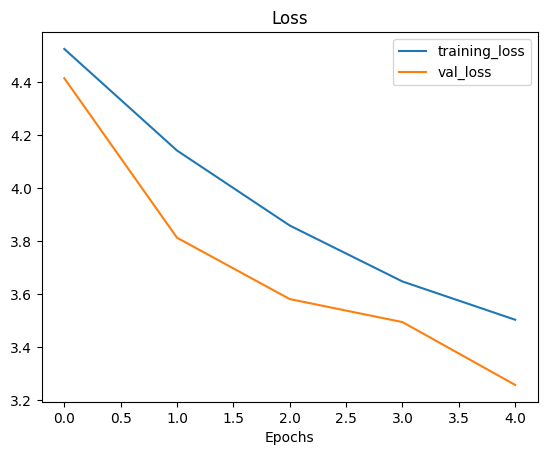

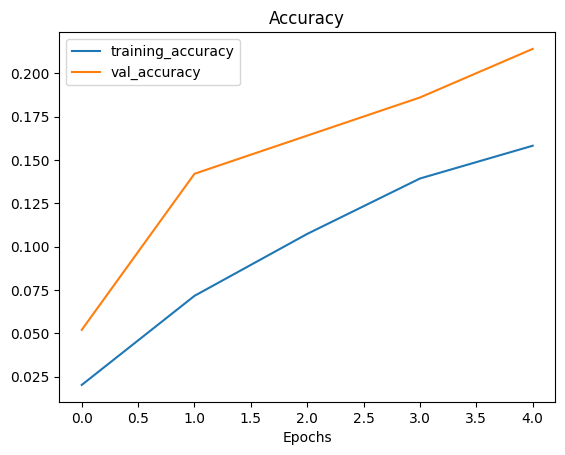

In [ ]:
plot_loss_curve(model_1_history)

In [ ]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size = 3,
                           activation = "relu",
                           input_shape=(224,224,3)
                           ),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(len(train_data.class_indices), activation="softmax")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_3.compile(loss= 'categorical_crossentropy',
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics = ["accuracy"])

In [ ]:
model_3_history = model_3.fit(train_data,
            epochs = 10,
            steps_per_epoch = len(train_data),
            validation_data = valid_data,
            validation_steps = len(valid_data),
            batch_size =32,
                              )

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 160s 368ms/step - accuracy: 0.0122 - loss: 4.6041 - val_accuracy: 0.0100 - val_loss: 4.6175
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 198s 364ms/step - accuracy: 0.0151 - loss: 4.5978 - val_accuracy: 0.0100 - val_loss: 4.6204
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 152s 360ms/step - accuracy: 0.0145 - loss: 4.5981 - val_accuracy: 0.0100 - val_loss: 4.6207
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 167s 395ms/step - accuracy: 0.0121 - loss: 4.5964 - val_accuracy: 0.0100 - val_loss: 4.6188
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 166s 392ms/step - accuracy: 0.0179 - loss: 4.5949 - val_accuracy: 0.0100 - val_loss: 4.6187
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 188s 360ms/step - accuracy: 0.0128 - loss: 4.5961 - val_accuracy: 0.0100 - val_loss: 4.6182
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 202s 361ms/step - accuracy: 0.0126 - loss: 4.5987 - val_accuracy: 0.0100 - val_loss: 4.6203
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 151s 357ms/step - accuracy: 0.0118 -

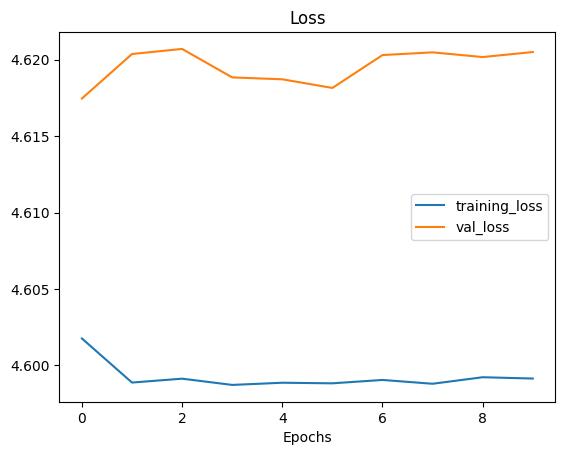

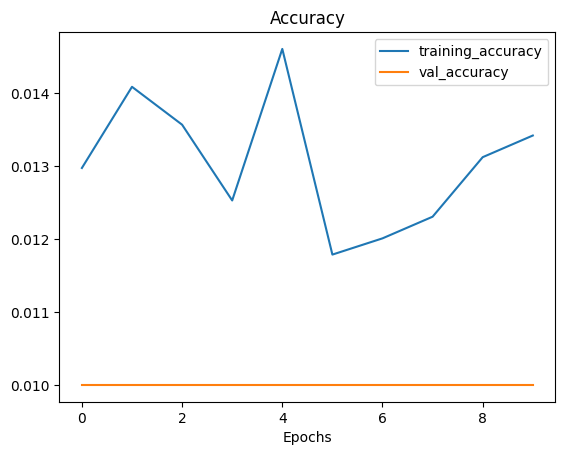

In [ ]:
plot_loss_curve(model_3_history)

### Improving the model using transfer learning

In [11]:
import tensorflow_hub as hub
import tensorflow as tf

# Resnet-50
model_resnet = "https://www.kaggle.com/models/tensorflow/resnet-50/TensorFlow2/feature-vector/1"

In [12]:
model_4 = tf.keras.Sequential([
    hub.KerasLayer(model_resnet),
    tf.keras.layers.Dense(len(train_data.class_indices), activation="softmax")
])

In [17]:
import tensorflow as tf
import datetime

def create_callbacks(dirname, experiment_name):
  log_dir = dirname + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

In [14]:
  # ! pip install tensorflow==2.15.0 tensorflow-hub keras==2.15.0
  # Had to downgrade my tensorflow in order to use tensorbaord

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt

In [14]:
model_4.compile(loss= 'categorical_crossentropy',
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

In [18]:
model_4_history = model_4.fit(train_data,
                              epochs = 5,
                              steps_per_epoch = len(train_data),
                              validation_data = valid_data,
                              validation_steps = len(valid_data),
                              batch_size = 32,
                              callbacks = [create_callbacks(dirname="tensorflow_hub",
                                                           experiment_name="model_4_resnet")])

Saving TensorBoard log files to: tensorflow_hub/model_4_resnet/20250502-161729
Epoch 1/5
422/422 [==============================] - 3155s 7s/step - loss: 1.2337 - accuracy: 0.6961 - val_loss: 0.2548 - val_accuracy: 0.9220
Epoch 2/5
422/422 [==============================] - 3131s 7s/step - loss: 0.3889 - accuracy: 0.8867 - val_loss: 0.2243 - val_accuracy: 0.9280
Epoch 3/5
422/422 [==============================] - 3191s 8s/step - loss: 0.2765 - accuracy: 0.9182 - val_loss: 0.1766 - val_accuracy: 0.9400
Epoch 4/5
422/422 [==============================] - 3058s 7s/step - loss: 0.2129 - accuracy: 0.9349 - val_loss: 0.1806 - val_accuracy: 0.9500
Epoch 5/5
422/422 [==============================] - 3090s 7s/step - loss: 0.1785 - accuracy: 0.9461 - val_loss: 0.1708 - val_accuracy: 0.9320


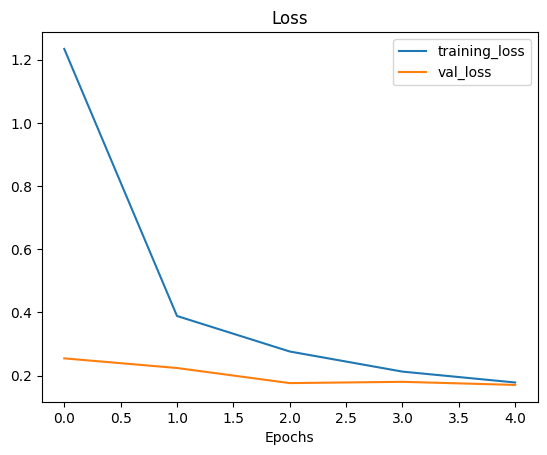

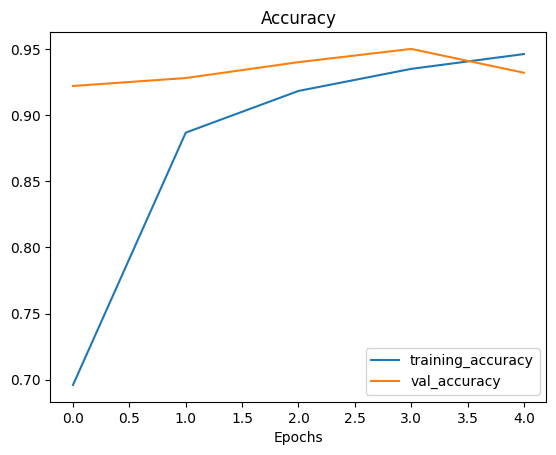

In [19]:
plot_loss_curve(model_4_history)

In [20]:
model_4.evaluate(test_data)

16/16 [==============================] - 104s 6s/step - loss: 0.1609 - accuracy: 0.9540


[0.16085965931415558, 0.9539999961853027]

In [34]:
class_names = []

for key, value in test_data.class_indices.items():
    class_names.append(key)

In [33]:
def load_and_prep_image(filename, img_shape=224, scale=True):
  """
  Reads in an image from filename, turns it into a tensor and reshapes into
  (224, 224, 3).

  Parameters
  ----------
  filename (str): string filename of target image
  img_shape (int): size to resize target image to, default 224
  scale (bool): whether to scale pixel values to range(0, 1), default True
  """
  # Read in the image
  img = tf.io.read_file(filename)
  # Decode it into a tensor
  img = tf.io.decode_image(img)
  # Resize the image
  img = tf.image.resize(img, [img_shape, img_shape])
  if scale:
    # Rescale the image (get all values between 0 and 1)
    return img/255.
  else:
    return img


1/1 [==============================] - 0s 205ms/step


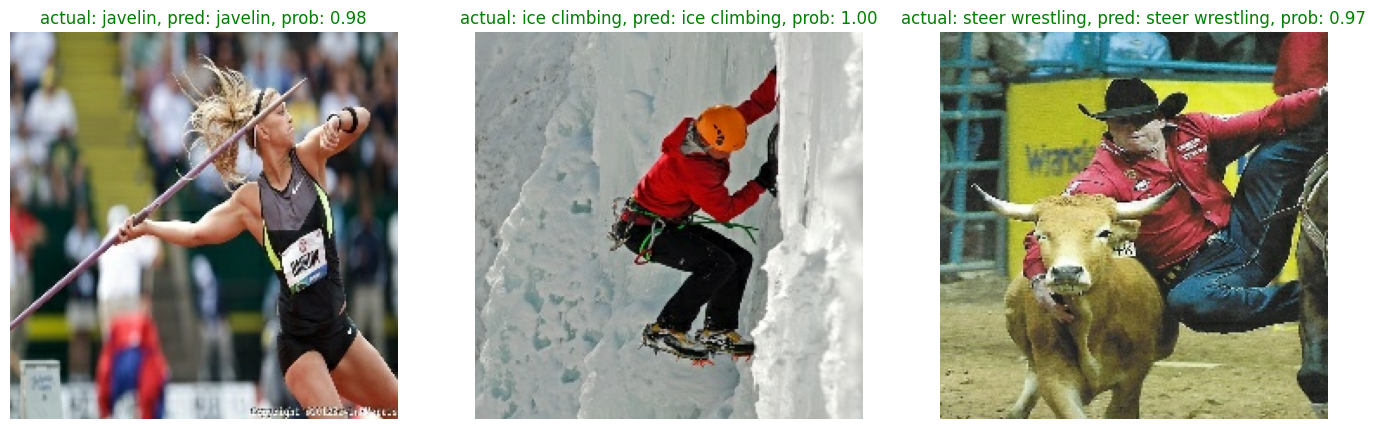

In [53]:

# Make preds on a series of random images
import os
import random

plt.figure(figsize=(17, 10))
for i in range(3):
  # Choose a random image from a random class
  class_name = random.choice(class_names)
  filename = random.choice(os.listdir(test_dir + "/" + class_name))
  filepath = test_dir + "/" + class_name + "/" + filename

  # Load the image and make predictions
  img = load_and_prep_image(filepath, scale=True)
  pred_prob = model_4.predict(tf.expand_dims(img, axis=0)) # model accepts tensors of shape [None, 224, 224, 3]
  pred_class = class_names[pred_prob.argmax()] # find the predicted class

  # Plot the image(s)
  plt.subplot(1, 3, i+1)
  plt.imshow(img)
  if class_name == pred_class: # Change the color of text based on whether prediction is right or wrong
    title_color = "g"
  else:
    title_color = "r"
  plt.title(f"actual: {class_name}, pred: {pred_class}, prob: {pred_prob.max():.2f}", c=title_color)
  plt.axis(False);

### Loading in custom images

(-0.5, 274.5, 182.5, -0.5)

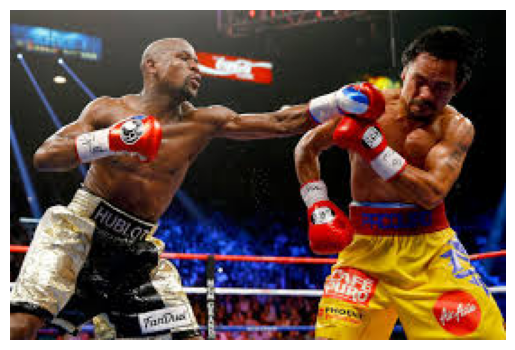

In [63]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
boxing = mpimg.imread("boxing.jpeg")

plt.imshow(boxing)
plt.axis(False)

In [72]:
boxing_ =load_and_prep_image("boxing.jpeg", scale=True)

In [73]:
model_4.predict(tf.expand_dims(boxing_, axis=0))

1/1 [==============================] - 0s 215ms/step


array([[1.4607807e-10, 1.5970349e-07, 2.4308182e-09, 3.9284487e-09,
        1.9639930e-07, 2.2626567e-10, 1.0522447e-07, 1.9275891e-08,
        1.4114694e-04, 3.8253206e-10, 3.5750648e-13, 6.9634670e-10,
        1.2019584e-10, 3.6495129e-10, 1.0491079e-08, 9.9812418e-01,
        1.4621194e-09, 9.8302955e-10, 1.7873529e-07, 1.1149626e-08,
        1.1778708e-12, 3.0426158e-08, 1.3898731e-13, 3.8567372e-09,
        8.4331830e-12, 1.3677773e-09, 2.9985255e-08, 8.6071766e-12,
        1.3832505e-10, 7.1467517e-13, 9.4356819e-15, 1.8738264e-07,
        1.9874980e-13, 5.9120736e-10, 9.0917149e-09, 6.3715775e-09,
        1.8609287e-08, 2.1693567e-07, 1.6324137e-12, 1.8172653e-12,
        1.6610686e-07, 7.1988666e-08, 2.2912550e-06, 4.8625454e-10,
        8.1134016e-10, 1.9464527e-05, 9.4611792e-12, 2.7143943e-11,
        4.4793829e-13, 2.2488736e-08, 2.2359893e-06, 5.0000329e-12,
        1.6020604e-10, 5.5752331e-10, 2.6296589e-06, 8.9284073e-09,
        3.2509567e-10, 9.5350932e-12, 8.8246147e

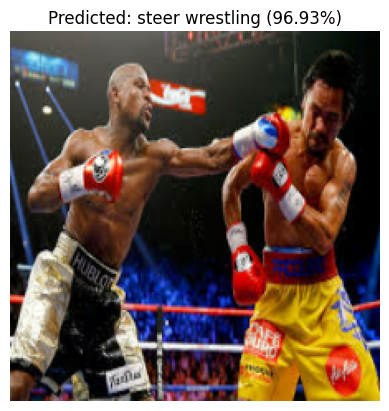

In [75]:
# 2. Get predicted class index and confidence
pred_class_idx = np.argmax(pred_prob)
pred_class = class_names[pred_class_idx]
confidence = np.max(pred_prob)

# 3. Visualize image with predicted label
plt.imshow(boxing_ )  # if boxing_ is a preprocessed image tensor
plt.title(f"Predicted: {pred_class} ({confidence:.2%})")
plt.axis(False)
plt.show()